<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/ssignment_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [1]:

# Install reuired libraries
!pip install fairlearn shap lime -q


# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

import shap
from lime.lime_tabular import LimeTabularExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 61.5 MB/s eta 0:00:00


# Data preparation

**Load dataset**

In [2]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (48842, 15)
   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week nativ

Income is the target variable

**Inspect columns**

In [3]:
print(df.columns)
print(df["class"].value_counts())
print(df["sex"].value_counts())

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')
class
<=50K    37155
>50K     11687
Name: count, dtype: int64
sex
Male      32650
Female    16192
Name: count, dtype: int64


**Define target and sensitive feature**

In [4]:
target_col = "class"         # income label
sensitive_col = "sex"        # fairness group

# Convert target to 0/1
df[target_col] = df[target_col].apply(lambda x: 1 if x == ">50K" else 0)

# Separate X, y, and sensitive feature
X = df.drop(columns=[target_col])
y = df[target_col]
A = df[sensitive_col]   # sensitive attribute for fairness analysis

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Sensitive attribute sample:")
print(A.head())

Features shape: (48842, 14)
Target shape: (48842,)
Sensitive attribute sample:
0      Male
1      Male
2      Male
3      Male
4    Female
Name: sex, dtype: category
Categories (2, object): ['Female', 'Male']


#Preprocessing

**Identify numeric and categorical columns**

In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


**Preprocessing pipeline**

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

#Train/Test Split and Logistic Regression

**Train-test split**

In [8]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (39073, 14)
Test shape: (9769, 14)


**logistic regression pipeline**

In [9]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

#Performance Evaluation

**Predictions**

In [10]:
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

Accuracy: 0.8524


# Confusion matrix

Confusion Matrix:
 [[6951  480]
 [ 962 1376]]


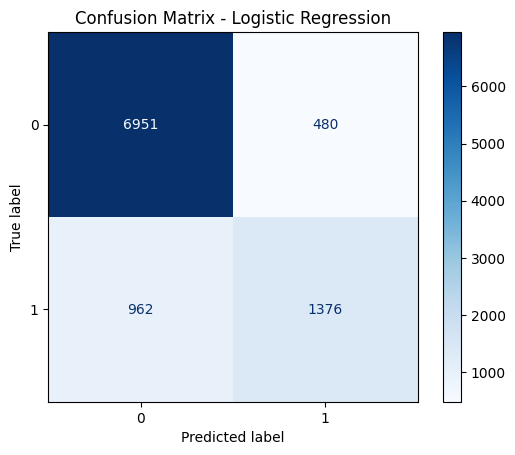

In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Classification Report**

In [12]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



#Fairness Analysis with Fairlearn

In [13]:
metrics = {
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("Overall fairness metrics:")
print(metric_frame.overall)

print("\nMetrics by group:")
print(metric_frame.by_group)

Overall fairness metrics:
selection_rate         0.189989
false_positive_rate    0.064594
true_positive_rate     0.588537
dtype: float64

Metrics by group:
        selection_rate  false_positive_rate  true_positive_rate
sex                                                            
Female        0.075790             0.022084            0.506925
Male          0.247158             0.091771            0.603440


# SHAP Explainability

**Get transformed training/test data**

In [14]:
X_train_transformed = model.named_steps["preprocessor"].fit_transform(X_train)
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrices to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

print("Transformed train shape:", X_train_transformed.shape)
print("Number of transformed features:", len(feature_names))

Transformed train shape: (39073, 105)
Number of transformed features: 105


**SHAP summary plot**

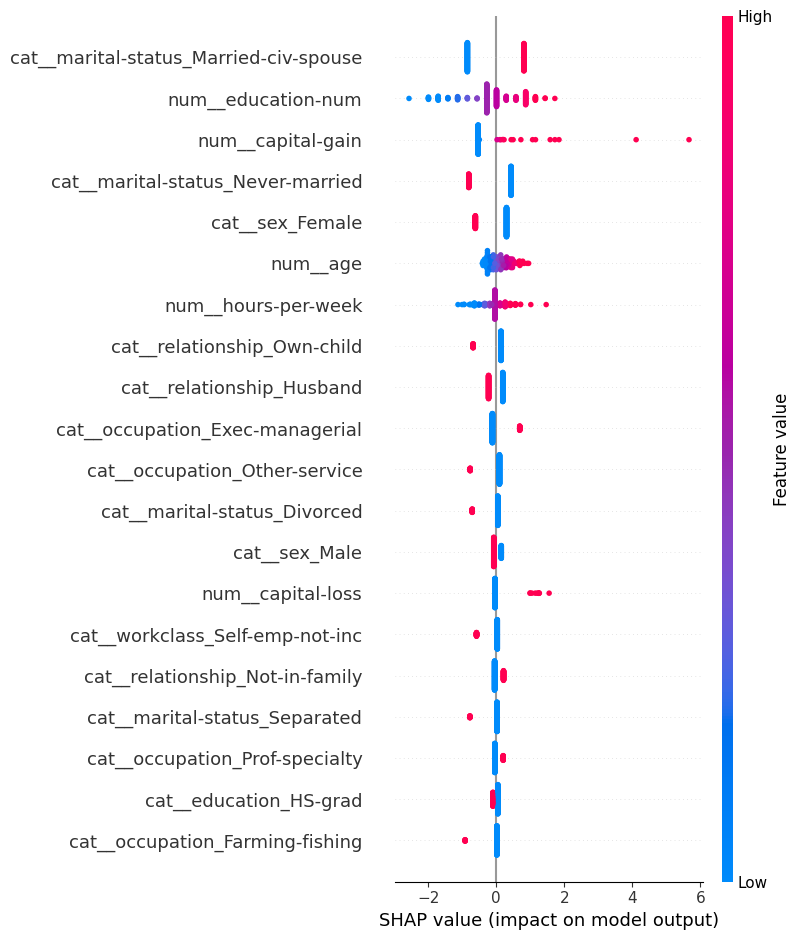

In [15]:
classifier = model.named_steps["classifier"]

explainer = shap.Explainer(
    classifier,
    X_train_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_test_transformed[:200])  # use subset for speed

shap.summary_plot(shap_values, X_test_transformed[:200], feature_names=feature_names)

**SHAP waterfall plot**

Actual label: 0
Predicted label: 0


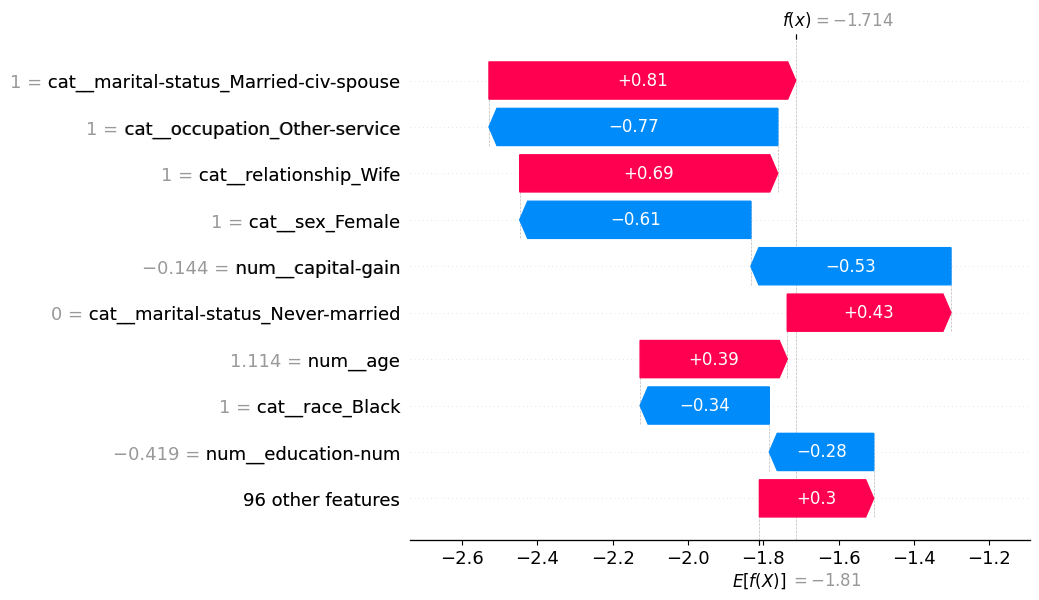

In [16]:
sample_index = 0

print("Actual label:", y_test.iloc[sample_index])
print("Predicted label:", y_pred[sample_index])

shap.plots.waterfall(shap_values[sample_index])

#LIME Explainability

**Prepare data for LIME**

In [19]:
# LIME needs encoded numeric array, so we use raw X_train converted carefully
X_train_lime = X_train.copy()
X_test_lime = X_test.copy()

# Convert categorical columns to numerical codes for LIME, and keep feature names
categorical_names = {}
for col in categorical_features:
    # Ensure the column is of 'category' dtype before getting codes
    X_train_lime[col] = X_train_lime[col].astype('category')
    X_test_lime[col] = X_test_lime[col].astype('category')

    # Store category names for LIME using the original column index
    original_col_idx = X.columns.get_loc(col)
    categorical_names[original_col_idx] = list(X_train_lime[col].cat.categories)

    # Convert to numerical codes
    X_train_lime[col] = X_train_lime[col].cat.codes
    X_test_lime[col] = X_test_lime[col].cat.codes

# LIME works better if we provide numpy arrays where all features are numeric
X_train_lime_np = X_train_lime.values
X_test_lime_np = X_test_lime.values

# Identify categorical column indexes (these are the indices in the original X/X_train_lime_np)
categorical_indices = [X.columns.get_loc(col) for col in categorical_features]

explainer_lime = LimeTabularExplainer(
    training_data=X_train_lime_np,
    feature_names=X.columns.tolist(),
    class_names=["<=50K", ">50K"],
    categorical_features=categorical_indices,
    categorical_names=categorical_names, # Provide categorical names for display
    mode="classification"
)

**LIME explanation for one test instance**

In [20]:
def predict_proba_lime(data):
    data_df = pd.DataFrame(data, columns=X.columns)
    for col in categorical_features:
        data_df[col] = data_df[col].astype(str)
    return model.predict_proba(data_df)

lime_index = 0

lime_exp = explainer_lime.explain_instance(
    data_row=X_test_lime_np[lime_index],
    predict_fn=predict_proba_lime,
    num_features=10
)

print("LIME explanation for test sample", lime_index)
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

LIME explanation for test sample 0
capital-gain <= 0.00: -0.6900
capital-loss <= 0.00: -0.1724
education-num <= 9.00: -0.1358
hours-per-week <= 40.00: -0.0795
age > 48.00: 0.0590
fnlwgt <= 117700.00: -0.0147
relationship=Wife: 0.0110
native-country=United-States: 0.0062
marital-status=Married-civ-spouse: 0.0052
workclass=Private: -0.0049
